# MediForecast AI — Pharmaceutical Demand Forecasting

This notebook predicts next month drug demand using:

- XGBoost Machine Learning
- Prophet Time Series
- LSTM Neural Network
- Ensemble Forecasting

Outputs:
- Restock alerts
- Demand prediction
- Excel report
- Charts

In [2]:
pip install pandas numpy joblib matplotlib seaborn scikit-learn xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/309.1 kB ? eta -:--:--
   


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

Matplotlib is building the font cache; this may take a moment.


In [12]:
def load_data(filepath="drug_monthly_training_data.csv"):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    if "NEXT_MONTH_QTY" in df.columns:
        df = df.drop(columns=["NEXT_MONTH_QTY"])

    df["DATE"] = pd.to_datetime(df[["YEAR", "MONTH"]].assign(DAY=1))
    df = df.sort_values(["DRUG_NAME", "DATE"]).reset_index(drop=True)

    print("Rows:", len(df))
    print("Drugs:", df["DRUG_NAME"].nunique())
    return df

df = load_data()
df.head()

Rows: 2160
Drugs: 48


,PERIOD,YEAR,MONTH,DRUG_NAME,CATEGORY,UNIT_PRICE_LKR,QTY_SOLD,REVENUE_LKR,STOCK_START,STOCK_END,...,STOCK_OUT,IS_MONSOON,LAG_1_QTY,LAG_2_QTY,LAG_3_QTY,LAG_12_QTY,ROLLING_3M_AVG,ROLLING_6M_AVG,YOY_GROWTH,DATE
0,2022-01,2022,1,Amlodipine 5mg,TABLET,7.5,5594,41955.0,465,0,...,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-01
1,2022-02,2022,2,Amlodipine 5mg,TABLET,7.5,4891,36682.5,485,0,...,1,0,5594.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-02-01
2,2022-03,2022,3,Amlodipine 5mg,TABLET,7.5,5241,39307.5,406,0,...,1,0,4891.0,5594.0,NaN,NaN,NaN,NaN,NaN,2022-03-01
3,2022-04,2022,4,Amlodipine 5mg,TABLET,7.5,4125,30937.5,624,0,...,1,0,5241.0,4891.0,5594.0,NaN,5242.00,NaN,NaN,2022-04-01
4,2022-05,2022,5,Amlodipine 5mg,TABLET,7.5,5558,41685.0,393,0,...,1,1,4125.0,5241.0,4891.0,NaN,4752.33,NaN,NaN,2022-05-01


In [13]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

def engineer_features(df):
    df = df.copy()
    
    # Label encoding
    le_drug = LabelEncoder()
    le_cat  = LabelEncoder()
    df["DRUG_ID"] = le_drug.fit_transform(df["DRUG_NAME"])
    df["CATEGORY_ID"] = le_cat.fit_transform(df["CATEGORY"])
    
    # Calendar features
    df["MONTH_SIN"] = np.sin(2 * np.pi * df["MONTH"]/12)
    df["MONTH_COS"] = np.cos(2 * np.pi * df["MONTH"]/12)
    df["QUARTER"] = ((df["MONTH"]-1)//3 + 1)
    df["IS_YEAR_END"] = (df["MONTH"]==12).astype(int)
    df["IS_YEAR_START"] = (df["MONTH"]==1).astype(int)
    
    # Sri Lanka seasonality flags
    df["IS_AVURUDU"] = (df["MONTH"]==4).astype(int)
    df["IS_VESAK"] = (df["MONTH"]==5).astype(int)
    df["IS_DEEPAVALI"] = df["MONTH"].isin([10,11]).astype(int)
    
    # Lag features
    for lag in [1,2,3,6,12]:
        df[f"LAG_{lag}"] = df.groupby("DRUG_NAME")["QTY_SOLD"].shift(lag)
    
    # Rolling averages
    g = df.groupby("DRUG_NAME")["QTY_SOLD"]
    df["ROLL_3_MEAN"] = g.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df["ROLL_6_MEAN"] = g.transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
    df["ROLL_12_MEAN"] = g.transform(lambda x: x.shift(1).rolling(12, min_periods=1).mean())
    
    # Momentum / YoY
    df["MOM_CHANGE"] = g.pct_change().fillna(0).clip(-1,5)
    df["YOY_CHANGE"] = df.groupby(["DRUG_NAME","MONTH"])["QTY_SOLD"].pct_change().fillna(0).clip(-1,5)
    
    # Stock-derived
    df["STOCK_RATIO"] = df["STOCK_END"] / (df["STOCK_START"] + 1)
    df["STOCK_CUSHION"] = (df["STOCK_END"] - df["STOCK_START"]).clip(lower=0)
    
    print("Feature engineering completed. Total columns:", len(df.columns))
    return df, le_drug, le_cat

# Run feature engineering
df, le_drug, le_cat = engineer_features(df)
df.head()

Feature engineering completed. Total columns: 43


,PERIOD,YEAR,MONTH,DRUG_NAME,CATEGORY,UNIT_PRICE_LKR,QTY_SOLD,REVENUE_LKR,STOCK_START,STOCK_END,...,LAG_3,LAG_6,LAG_12,ROLL_3_MEAN,ROLL_6_MEAN,ROLL_12_MEAN,MOM_CHANGE,YOY_CHANGE,STOCK_RATIO,STOCK_CUSHION
0,2022-01,2022,1,Amlodipine 5mg,TABLET,7.5,5594,41955.0,465,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0
1,2022-02,2022,2,Amlodipine 5mg,TABLET,7.5,4891,36682.5,485,0,...,NaN,NaN,NaN,5594.000000,5594.00,5594.00,-0.125670,0.0,0.0,0
2,2022-03,2022,3,Amlodipine 5mg,TABLET,7.5,5241,39307.5,406,0,...,NaN,NaN,NaN,5242.500000,5242.50,5242.50,0.071560,0.0,0.0,0
3,2022-04,2022,4,Amlodipine 5mg,TABLET,7.5,4125,30937.5,624,0,...,5594.0,NaN,NaN,5242.000000,5242.00,5242.00,-0.212936,0.0,0.0,0
4,2022-05,2022,5,Amlodipine 5mg,TABLET,7.5,5558,41685.0,393,0,...,4891.0,NaN,NaN,4752.333333,4962.75,4962.75,0.347394,0.0,0.0,0


In [ ]:
FEATURE_COLS = [...]
train_xgboost()

In [18]:
# Make sure the columns exist
df = df.sort_values(["DRUG_NAME", "DATE"])

# Rolling statistics
grouped = df.groupby("DRUG_NAME")["QTY_SOLD"]

df["ROLL_3_STD"] = grouped.transform(lambda x: x.shift(1).rolling(3, min_periods=2).std()).fillna(0)
df["ROLL_3_MAX"] = grouped.transform(lambda x: x.shift(1).rolling(3, min_periods=1).max())
df["ROLL_3_MIN"] = grouped.transform(lambda x: x.shift(1).rolling(3, min_periods=1).min())

# Lag features if not already
for lag in [1,2,3,6,12]:
    col_name = f"LAG_{lag}"
    if col_name not in df.columns:
        df[col_name] = grouped.shift(lag)

# Trend features
df["MOM_CHANGE"] = grouped.pct_change().fillna(0).clip(-1,5)
df["YOY_CHANGE"] = grouped.pct_change(12).fillna(0).clip(-1,5)

# Stock-derived features
df["STOCK_RATIO"]   = df["STOCK_END"] / (df["REORDER_LEVEL"] + 1)
df["STOCK_CUSHION"] = (df["STOCK_END"] - df["REORDER_LEVEL"]).clip(lower=0)

print("Feature engineering complete. Columns now include rolling & trend features.")
df.head()

Feature engineering complete. Columns now include rolling & trend features.


,PERIOD,YEAR,MONTH,DRUG_NAME,CATEGORY,UNIT_PRICE_LKR,QTY_SOLD,REVENUE_LKR,STOCK_START,STOCK_END,...,ROLL_3_MEAN,ROLL_6_MEAN,ROLL_12_MEAN,MOM_CHANGE,YOY_CHANGE,STOCK_RATIO,STOCK_CUSHION,ROLL_3_STD,ROLL_3_MAX,ROLL_3_MIN
0,2022-01,2022,1,Amlodipine 5mg,TABLET,7.5,5594,41955.0,465,0,...,NaN,NaN,NaN,0.000000,0.0,0.0,0,0.000000,NaN,NaN
1,2022-02,2022,2,Amlodipine 5mg,TABLET,7.5,4891,36682.5,485,0,...,5594.000000,5594.00,5594.00,-0.125670,0.0,0.0,0,0.000000,5594.0,5594.0
2,2022-03,2022,3,Amlodipine 5mg,TABLET,7.5,5241,39307.5,406,0,...,5242.500000,5242.50,5242.50,0.071560,0.0,0.0,0,497.096067,5594.0,4891.0
3,2022-04,2022,4,Amlodipine 5mg,TABLET,7.5,4125,30937.5,624,0,...,5242.000000,5242.00,5242.00,-0.212936,0.0,0.0,0,351.501067,5594.0,4891.0
4,2022-05,2022,5,Amlodipine 5mg,TABLET,7.5,5558,41685.0,393,0,...,4752.333333,4962.75,4962.75,0.347394,0.0,0.0,0,570.776080,5241.0,4125.0


In [19]:
FEATURE_COLS = [
    "DRUG_ID", "CATEGORY_ID", "MONTH", "YEAR", "QUARTER",
    "MONTH_SIN", "MONTH_COS", "IS_MONSOON",
    "IS_YEAR_END", "IS_YEAR_START", "IS_AVURUDU", "IS_VESAK", "IS_DEEPAVALI",
    "LAG_1", "LAG_2", "LAG_3", "LAG_6", "LAG_12",
    "ROLL_3_MEAN", "ROLL_6_MEAN", "ROLL_12_MEAN",
    "ROLL_3_STD", "ROLL_3_MAX", "ROLL_3_MIN",
    "MOM_CHANGE", "YOY_CHANGE",
    "UNIT_PRICE_LKR", "REORDER_LEVEL",
    "STOCK_RATIO", "STOCK_CUSHION",
]

TARGET_COL = "QTY_SOLD"

In [20]:
from sklearn.preprocessing import LabelEncoder

# Encode drugs and categories
le_drug = LabelEncoder()
df["DRUG_ID"] = le_drug.fit_transform(df["DRUG_NAME"])

le_cat = LabelEncoder()
df["CATEGORY_ID"] = le_cat.fit_transform(df["CATEGORY"])

In [21]:
# Drop rows with missing feature values
df_train = df.dropna(subset=FEATURE_COLS).copy()

# Time-based split: last 6 months as validation
split_date = df_train["DATE"].max() - pd.DateOffset(months=6)
train_mask = df_train["DATE"] <= split_date
val_mask   = df_train["DATE"] >  split_date

X_train = df_train.loc[train_mask, FEATURE_COLS]
y_train = df_train.loc[train_mask, TARGET_COL]

X_val   = df_train.loc[val_mask, FEATURE_COLS]
y_val   = df_train.loc[val_mask, TARGET_COL]

In [22]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Fit the model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-rmse:5292.89589
[50]	validation_0-rmse:667.86755
[100]	validation_0-rmse:305.69780
[150]	validation_0-rmse:287.18160
[200]	validation_0-rmse:287.05383
[250]	validation_0-rmse:286.25632
[300]	validation_0-rmse:285.56981
[350]	validation_0-rmse:284.80632
[400]	validation_0-rmse:284.67793
[450]	validation_0-rmse:284.30002
[499]	validation_0-rmse:283.98492


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [23]:
y_pred = xgb_model.predict(X_val)

mae  = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2   = r2_score(y_val, y_pred)
mape = np.mean(np.abs((y_val - y_pred) / (y_val + 1))) * 100

print(f"MAE: {mae:.1f} | RMSE: {rmse:.1f} | R²: {r2:.3f} | MAPE: {mape:.1f}%")

MAE: 120.5 | RMSE: 284.0 | R²: 0.997 | MAPE: 4.8%


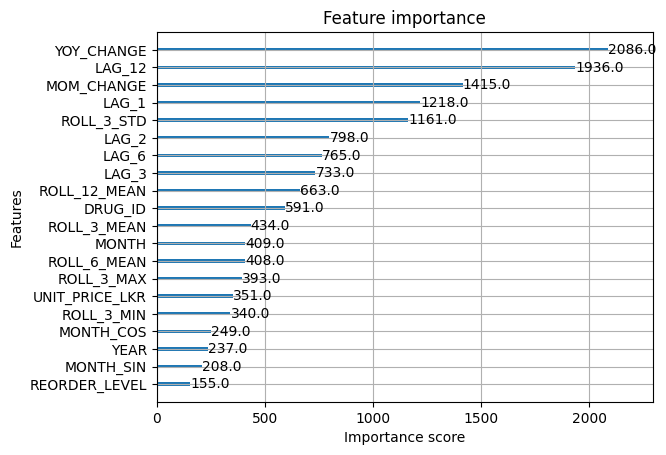

In [24]:
import matplotlib.pyplot as plt

xgb.plot_importance(xgb_model, max_num_features=20)
plt.show()

In [25]:
next_month_features = df[FEATURE_COLS].tail(len(df['DRUG_NAME'].unique()))
pred_next_month = xgb_model.predict(next_month_features)

next_month_df = df[['DRUG_NAME', 'DATE']].tail(len(df['DRUG_NAME'].unique())).copy()
next_month_df['PRED_QTY_NEXT_MONTH'] = pred_next_month
print(next_month_df)

                    DRUG_NAME       DATE  PRED_QTY_NEXT_MONTH
2112          Vitamin C 500mg 2025-07-01           828.727478
2113          Vitamin C 500mg 2025-08-01           900.107727
2114          Vitamin C 500mg 2025-09-01           769.045959
2115  Zinc Oxide Ointment 30g 2022-01-01         22022.410156
2116  Zinc Oxide Ointment 30g 2022-02-01         17598.496094
2117  Zinc Oxide Ointment 30g 2022-03-01         17942.544922
2118  Zinc Oxide Ointment 30g 2022-04-01         17656.910156
2119  Zinc Oxide Ointment 30g 2022-05-01         18044.644531
2120  Zinc Oxide Ointment 30g 2022-06-01         17810.816406
2121  Zinc Oxide Ointment 30g 2022-07-01         17932.744141
2122  Zinc Oxide Ointment 30g 2022-08-01         17823.210938
2123  Zinc Oxide Ointment 30g 2022-09-01         17679.777344
2124  Zinc Oxide Ointment 30g 2022-10-01         18111.257812
2125  Zinc Oxide Ointment 30g 2022-11-01         17690.552734
2126  Zinc Oxide Ointment 30g 2022-12-01         17675.707031
2127  Zi

In [26]:
import joblib
joblib.dump(xgb_model, "xgb_drug_demand_model.pkl")

['xgb_drug_demand_model.pkl']

In [27]:
next_month_features = df[FEATURE_COLS].tail(len(df['DRUG_NAME'].unique()))
predictions = xgb_model.predict(next_month_features)

In [28]:
next_month_df = df[['DRUG_NAME', 'DATE']].tail(len(df['DRUG_NAME'].unique())).copy()
next_month_df['PRED_QTY_NEXT_MONTH'] = predictions
next_month_df.to_csv("next_month_demand.csv", index=False)